# Artificial Intelligence Technology and Application

## Deep Learning Lab Guide - Student Version

Independent implementation prepared by **Sundetkhan Bekzat**.


# 1 MNIST Handwritten Character Recognition

This notebook keeps the lab objective but uses compact local examples so it can run without external datasets.


## 1.1 Digits Dataset
Scikit-learn's digits data gives a small local handwritten-number task.


In [1]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, stratify=digits.target, random_state=12)
scaler = StandardScaler().fit(X_train)
print("images:", digits.images.shape)


images: (1797, 8, 8)


## 1.2 Dense Neural Classifier
A small MLP mirrors the dense-network portion of an MNIST workflow.


In [2]:
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(48, 24), activation="relu", max_iter=180, random_state=12, early_stopping=True)
mlp.fit(scaler.transform(X_train), y_train)
predictions = mlp.predict(scaler.transform(X_test))
print("accuracy:", round(accuracy_score(y_test, predictions), 3))
print("iterations:", mlp.n_iter_)


accuracy: 0.904
iterations: 29


## 1.3 Prediction Grid
A few predicted digits are shown for visual inspection.


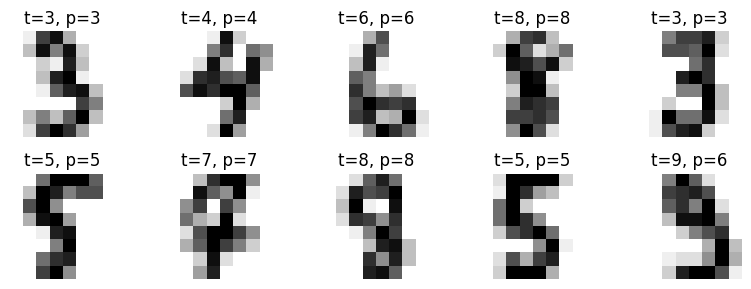

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(8, 3))
for ax, image, truth, pred in zip(axes.ravel(), X_test[:10].reshape(-1, 8, 8), y_test[:10], predictions[:10]):
    ax.imshow(image, cmap="gray_r")
    ax.set_title(f"t={truth}, p={pred}")
    ax.axis("off")
plt.tight_layout()
plt.show()
